In [8]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [3]:
vNumSamples = [50, 150, 500, 100] # number of sample in every cluster
mMu = [[0,0], [2, 2], [-2.5, -2.5], [-4, 4]] # averages values for for centers of distributions in two dimensions
vClusterStd = [0.1, 1, 2, 1.5] # standard deviations for every distribution

In [4]:
mX, vL = make_blobs(n_samples=vNumSamples, n_features=2, centers=mMu, cluster_std=vClusterStd)

In [10]:
vU = np.unique(vL)
numClusters = len(vU)

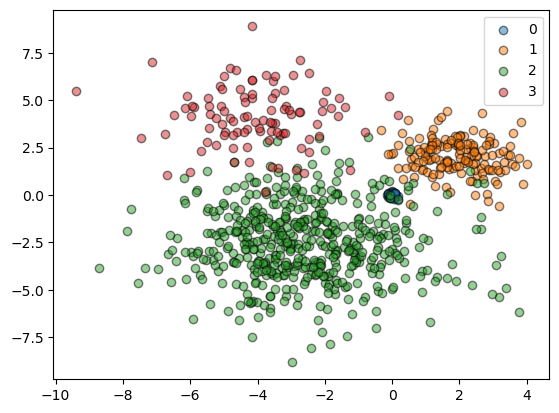

In [12]:
fig, ax = plt.subplots()

for ii in range(numClusters):
    vIdx = vL == vU[ii] # indexes which belong to the certain class
    ax.scatter(mX[vIdx, 0], mX[vIdx, 1], alpha=0.5, edgecolors='k', label = ii )
plt.legend()

In [40]:
from sklearn.mixture import GaussianMixture
oGmm = GaussianMixture(n_components=4, max_iter=100, init_params='kmeans', random_state=42) # definition of GMM clustering object
oGmm.fit(mX)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [41]:
vIdx = oGmm.predict(mX)
vIdx.shape

(800,)

In [49]:
vL = np.unique(vIdx)

In [50]:
vL

array([0, 1, 2, 3])

In [42]:
mMu = oGmm.means_

In [43]:
mMu

array([[-1.88517092, -3.62035646],
       [-3.57048425, -1.73830206],
       [ 1.25362481,  1.33980377],
       [-3.9404067 ,  4.02455015]])

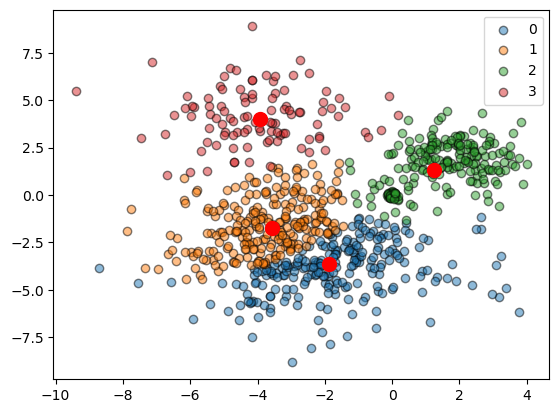

In [51]:
fig, ax = plt.subplots()
for ii in range(len(vL)):
    ax.scatter(mX[vIdx == vL[ii] , 0], mX[vIdx == vL[ii], 1], edgecolors='k', alpha=0.5, label=ii)

ax.plot(mMu[:, 0], mMu[:, 1], '.r', markersize=20)

plt.legend()

In [47]:
mC = oGmm.covariances_[0]

In [48]:
mC

array([[4.19138933, 0.32132681],
       [0.32132681, 2.56689781]])

In [53]:
v, w = np.linalg.eig(mC)

In [62]:
v

array([4.2526389 , 2.50564824])

array([[ 0.98231357, -0.18724328],
       [ 0.18724328,  0.98231357]])

In [65]:
index = np.argmax(v)
index

np.int64(0)

In [ ]:
u = w[:, index] # 
u

array([0.98231357, 0.18724328])

In [68]:
angle = np.arctan2(u[1], u[0])
angle

np.float64(0.18835503593684935)

In [69]:
angle = 180 * angle / np.pi
angle

np.float64(10.791948609216417)

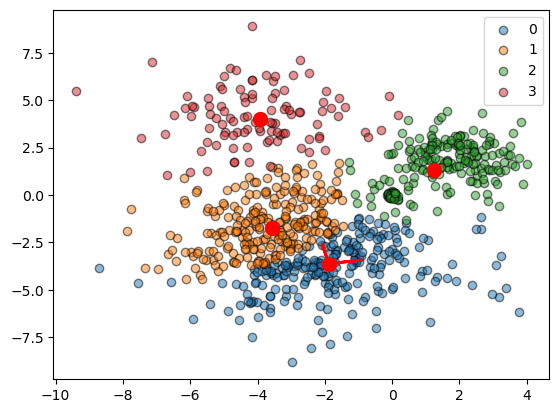

In [61]:
fig, ax = plt.subplots()
for ii in range(len(vL)):
    ax.scatter(mX[vIdx == vL[ii] , 0], mX[vIdx == vL[ii], 1], edgecolors='k', alpha=0.5, label=ii)

ax.plot(mMu[:, 0], mMu[:, 1], '.r', markersize=20)
ax.arrow(mMu[0, 0], mMu[0, 1], w[0, 0], w[1, 0], linewidth=2, color='red')
ax.arrow(mMu[0, 0], mMu[0, 1], w[0, 1], w[1, 1], linewidth=2, color='red')
plt.legend()
plt.show()